NicheNet’s ligand activity analysis on a gene set of interest: predict
active ligands and their target genes
================

This vignette follows the steps described in [Perform NicheNet analysis: step-by-step analysis](steps.ipynb)
with two major differences: a predefined gene set of interest is given,
and a different definition of expressed genes.

Here, we use explore intercellular communication in the tumor
microenvironment of head and neck squamous cell carcinoma (HNSCC) (Puram
et al. 2017). More specifically, we will look at which ligands expressed
by cancer-associated fibroblasts (CAFs) can induce a specific gene
program in neighboring malignant cells. The original authors of the
study have linked this partial epithelial-mesenschymal transition
(p-EMT) program to metastasis.

The used [ligand-target matrix](https://doi.org/10.5281/zenodo.7074290)
and example [expression data](https://doi.org/10.5281/zenodo.3260758) of
interacting cells can be downloaded from Zenodo.

# Prepare NicheNet analysis

### Load packages

In [1]:
from nichenetpy.prediction import LigandActivityPredictor
from nichenetpy.network import (
    LigandReceptorNetwork,
    WeightedNetwork
)
from nichenetpy.utils import (
    read_matrix_from_csv,
    read_csv_rows,
    subset_matrix
)
from nichenetpy.wrappers import (
    combine_weighted_ligand_target_links,
    get_weighted_ligand_receptor_links,
    create_regulatory_potential_heatmap,
    create_prior_interaction_potential_heatmap,
    create_ligand_activity_heatmap
)
from nichenetpy.gene_symbol import human_alias_info
from nichenetpy.visualization import heatmap_2d

from math import log
from sklearn.preprocessing import quantile_transform

import pandas as pd

## Read in NicheNet's networks

The ligand-target prior model is a matrix describing the potential that a ligand may regulate a target gene, and it is used to run the ligand activity analysis. The ligand-receptor network contains information on potential ligand-receptor bindings, and it is used to identify potential ligands. 

In [2]:
# set the paths to that of your local copies (these files are too large to upload to the remote git repo)
predictor = LigandActivityPredictor(*read_matrix_from_csv("D:/Data/nichenetpy/model/human/csv/ligand_target_matrix.csv"))
lr_network = LigandReceptorNetwork(filename="D:/Data/nichenetpy/model/human/csv/lr_network.csv")

### Read in the expression data of interacting cells

This is publicly available single-cell data from CAF and malignant cells
from HNSCC tumors.

In [3]:
# set the paths to that of your local copies (these files are too large to upload to the remote git repo)
exp_mat, rows, cols = read_matrix_from_csv("D:/Data/hnscc/expression.csv")
cols = human_alias_info.alias_to_symbol(cols)
sample_info_col_names, sample_info = read_csv_rows("D:/Data/hnscc/sample_info.csv")

## 1. Define a set of potential ligands

Our research question is to prioritize which ligands expressed by CAFs
can induce p-EMT in neighboring malignant cells. Hence, we will only use
on the **sender-focused** approach, with CAFs as senders and malignant
cells as receivers.

The set of potential ligands is defined as ligands that are expressed in
sender cells whose cognate receptors are also expressed in receiver
cells.

So first, we will determine which genes are expressed in the sender
cells (CAFs) and receiver cells (malignant cells). We will only consider
samples from high quality primary tumors and also remove samples from
lymph node metastases. We will use the definition of expressed genes by
the original authors, that is, the aggregate expression of each gene $i$
across the $k$ cells, calculated as
$E_a(i) = log_{2}(average(TPM(i)1…k)+1)$, should be \>= 4.

We recommend users to define expressed genes in the way that they
consider to be most appropriate for their dataset. For single-cell data
generated by the 10x platform in our lab, we consider genes to be
expressed in a cell type when they have non-zero values in a certain
fraction of the cells from that cell type (usually 10%). This is used in
the vignette [Perform NicheNet analysis:
step-by-step analysis](steps.ipynb).

In [4]:
print(sample_info_col_names)
sample_info = [
    [
        int(processed_by_Maxima_enzyme),
        int(Lymph_node),
        int(classified_as_cancer_cell),
        int(classified_as_non_cancer_cells),
        non_cancer_cell_type,
        cell,
        tumor
    ]
    for
        processed_by_Maxima_enzyme,
        Lymph_node,
        classified_as_cancer_cell,
        classified_as_non_cancer_cells,
        non_cancer_cell_type,
        cell,
        tumor
    in sample_info
]

['processed by Maxima enzyme', 'Lymph node', 'classified  as cancer cell', 'classified as non-cancer cells', 'non-cancer cell type', 'cell', 'tumor']


In [5]:
tumors_remove = ["HN10","HN","HN12", "HN13", "HN24", "HN7", "HN8","HN23"]
CAF_cells = [e[5] for e in sample_info if e[1] == 0 and e[4] == "CAF" and e[6] not in tumors_remove]
malignant_cells = [e[5] for e in sample_info if e[1] == 0 and e[2] == 1 and e[6] not in tumors_remove]
row2id = dict(zip(rows, range(len(rows))))

def get_exp(mat, cols):
    agg_exp = [
        log(sum((10*(2**x - 1) for x in mat[:, i]))/mat.shape[0] + 1, 2)
        for i in range(mat.shape[1])
    ]
    return {gene for gene, x in zip(cols, agg_exp) if x >= 4}

expressed_genes_sender = get_exp(subset_matrix(exp_mat, [row2id[cell] for cell in CAF_cells]), cols)
expressed_genes_receiver = get_exp(subset_matrix(exp_mat, [row2id[cell] for cell in malignant_cells]), cols)

In [6]:
len(expressed_genes_sender)

6706

In [7]:
len(expressed_genes_receiver)

6351

Now, we can filter the expressed ligands and receptors to only those that putatively bind together. This information is stored in NicheNet’s ligand-receptor network by gathering various data sources.

In [8]:
ligands = lr_network.get_ligands()
expressed_ligands = ligands.intersection(expressed_genes_sender)
receptors = lr_network.get_receptors()
expressed_receptors = receptors.intersection(expressed_genes_receiver)
potential_ligands = {ligand for ligand, receptor in lr_network if ligand in expressed_ligands and receptor in expressed_receptors}

## 2. Define the gene set of interest and a background of genes

The gene set of interest consists of genes for which the expression is possibly affected due to communication with other cells. The definition of this gene set depends on your research question and is a crucial step in the use of NicheNet.

Here, we will use the p-EMT gene set defined by the original authors as gene set of interest to investigate how CAFs can induce p-EMT in malignant cells.

In [9]:
with open("D:/Data/nichenetpy/other/pemt_signature.txt") as file:
    geneset = file.readlines()
lt_ligands = set(predictor.row_names)
geneset = {gene.rstrip() for gene in geneset}.intersection(lt_ligands)

In [10]:
len(geneset)

96

## 3. Define background genes
We will define all genes expressed in malignant cells as the background set.

In [11]:
background_expressed_genes = expressed_genes_receiver.intersection(lt_ligands)

In [12]:
len(background_expressed_genes)

6281

## 4. Perform NicheNet ligand activity analysis
With the ligand activity analysis, we assess how well each CAF-ligand can predict the p-EMT gene set compared to the background of expressed genes.

In [13]:
ligand_activities = predictor.predict_ligand_activities(
    geneset,
    background_expressed_genes,
    potential_ligands
)

Ligands are ranked based on the area under the precision-recall curve (AUPR) between a ligand’s target predictions and the observed transcriptional response. Although other metrics like the AUROC and pearson correlation coefficient are also computed, we demonstrated in
our validation study that the AUPR was the most informative measure to define ligand activity (this was the Pearson correlation for v1). The vignette on how we performed the validation can be found at [Evaluation of NicheNet’s ligand-target predictions](https://github.com/saeyslab/nichenetr/blob/master/vignettes/model_evaluation.md).

In [14]:
ligand_activities_sorted = sorted(ligand_activities.items(), key=lambda x : x[1]["aupr_corrected"], reverse=True)
best_upstream_ligands = [e[0] for e in ligand_activities_sorted[:30]]

In [15]:
best_upstream_ligands[:10]

['TGFB2',
 'BMP8A',
 'INHBA',
 'CXCL12',
 'LTBP1',
 'CCN2',
 'TNXB',
 'ENG',
 'BMP5',
 'VCAN']

## 5. Infer target genes and receptors of top-ranked ligands
Active target genes are defined as genes in the gene set of interest that have the highest regulatory potential for each top-ranked ligand. These top targets of each ligand are based on the prior model. Specifically, the function get_weighted_ligand_target_links will return genes that are in the gene set of interest and are the top n targets of a ligand.

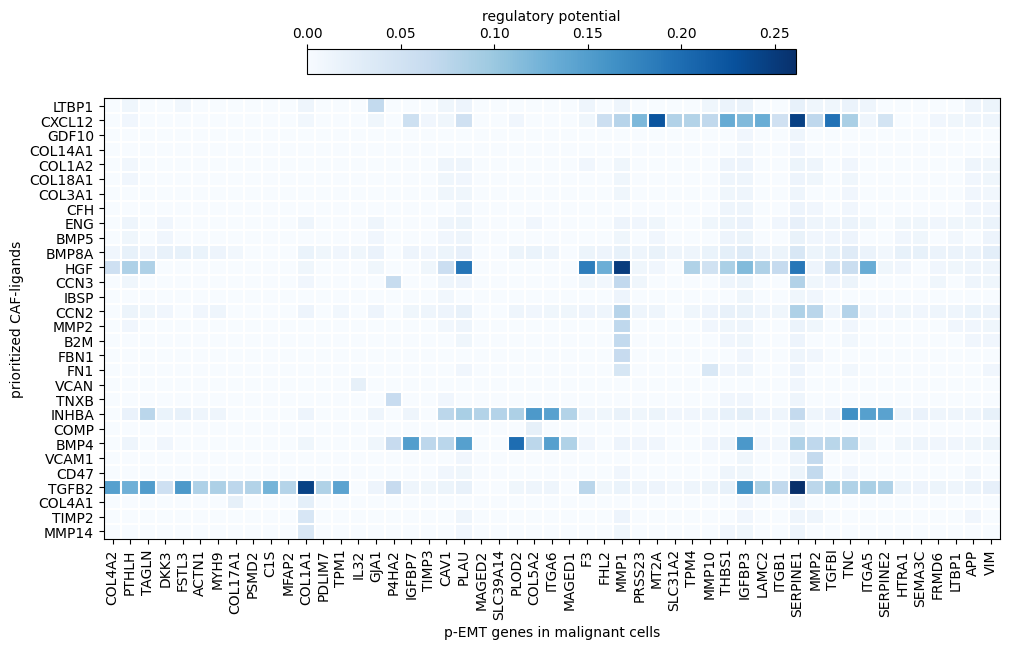

In [16]:
active_ligand_target_links = combine_weighted_ligand_target_links((
    predictor.get_weighted_ligand_target_links(ligand, geneset, n=200)
    for ligand in best_upstream_ligands
))
create_regulatory_potential_heatmap(
    predictor,
    active_ligand_target_links,
    xtitle="p-EMT genes in malignant cells",
    ytitle="prioritized CAF-ligands",
    figsize=(10, 6)
)

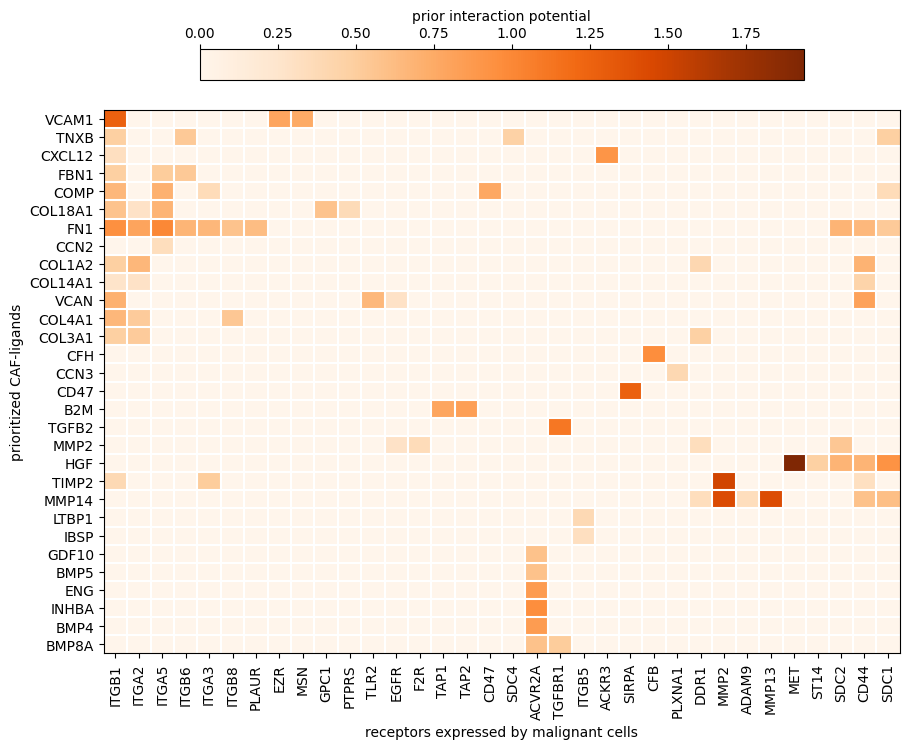

In [17]:
lr_sig = WeightedNetwork(filename="D:/Data/nichenetpy/model/human/csv/lr_sig.csv")
ligand_receptor_links = get_weighted_ligand_receptor_links(
    best_upstream_ligands,
    expressed_receptors,
    lr_network,
    lr_sig
)
create_prior_interaction_potential_heatmap(
    ligand_receptor_links,
    xtitle="receptors expressed by malignant cells",
    ytitle="prioritized CAF-ligands",
    figsize=(9, 7)
)

## 6. Summary visualizations of the NicheNet analysis

### Prepare the ligand activity matrix

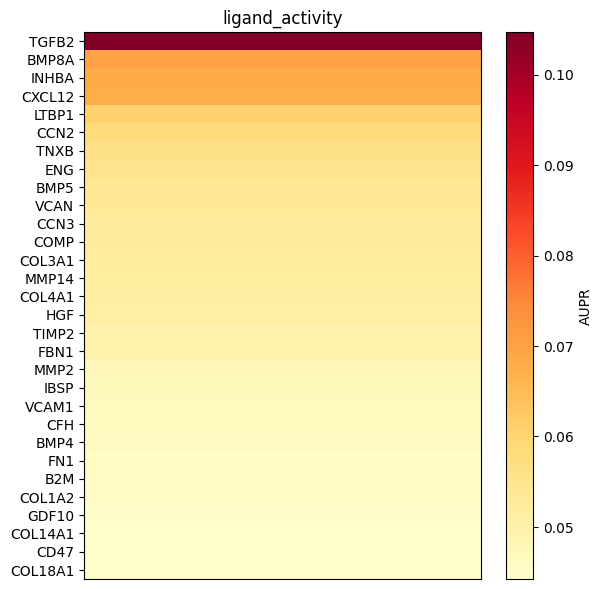

In [18]:
create_ligand_activity_heatmap(
    ligand_activities_sorted[:30],
)

### Prepare expression of ligands in fibroblast per tumor

Because the single-cell data was collected from multiple tumors, we will show here the average expression of the ligands per tumor.

In [19]:
col2id = dict(zip(cols, range(len(cols))))
exp_mat_caf = subset_matrix(
    exp_mat,
    [row2id[cell] for cell in CAF_cells],
    [col2id[ligand] for ligand in best_upstream_ligands]
)
exp_df_caf = pd.DataFrame(
    exp_mat_caf,
    index=CAF_cells,
    columns=best_upstream_ligands
)
exp_df_caf.index.name = 'cell'
exp_df_caf.reset_index(inplace=True)
sample_info = pd.DataFrame(
    sample_info,
    columns=sample_info_col_names
)
exp_df_caf = exp_df_caf.merge(sample_info[["cell", "tumor"]], on="cell", how="inner")
agg_exp_caf = exp_df_caf[exp_df_caf.columns.difference(["cell"])].groupby("tumor").mean()
agg_exp_caf.reset_index(inplace=True)
tumors = list(agg_exp_caf["tumor"])
agg_exp_caf = agg_exp_caf[agg_exp_caf.columns.difference(["tumor"])]
agg_exp_caf = agg_exp_caf.transpose()
agg_exp_caf.columns = tumors
# This order was determined based on the paper from Puram et al. Tumors are ordered according to p-EMT score.
agg_exp_caf = agg_exp_caf[["HN6","HN20","HN26","HN28","HN22","HN25","HN5","HN18","HN17","HN16"]]

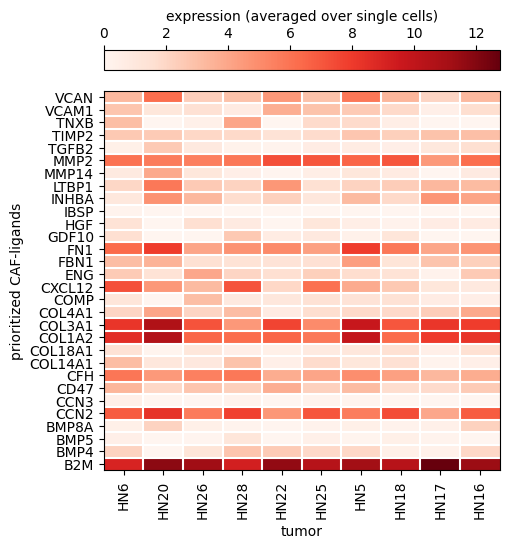

In [20]:
fig, ax = heatmap_2d(
    agg_exp_caf.values,
    xlabels=agg_exp_caf.columns,
    ylabels=agg_exp_caf.index,
    xtitle="tumor",
    ytitle="prioritized CAF-ligands",
    cbar_label="expression (averaged over single cells)",
    cmap="Reds"
)

### Prepare expression of target genes in malignant cells per tumor

In [21]:
exp_mat_target = subset_matrix(
    exp_mat,
    [row2id[cell] for cell in malignant_cells],
    [col2id[gene] for gene in geneset]
)
exp_df_target = pd.DataFrame(
    exp_mat_target,
    index=malignant_cells,
    columns=list(geneset)
)
exp_df_target.index.name = 'cell'
exp_df_target.reset_index(inplace=True)
exp_df_target = exp_df_target.merge(sample_info[["cell", "tumor"]], on="cell", how="inner")
agg_exp_target = exp_df_target[exp_df_target.columns.difference(["cell"])].groupby("tumor").mean()
agg_exp_target.reset_index(inplace=True)
tumors = list(agg_exp_target["tumor"])
agg_exp_target = agg_exp_target[agg_exp_target.columns.difference(["tumor"])]
agg_exp_target = agg_exp_target.transpose()
agg_exp_target.columns = tumors
targets = list({target for _, target, _ in active_ligand_target_links})
# This order was determined based on the paper from Puram et al. Tumors are ordered according to p-EMT score.
agg_exp_target = agg_exp_target[["HN6","HN20","HN26","HN28","HN22","HN25","HN5","HN18","HN17","HN16"]]
agg_exp_target = agg_exp_target.loc[targets].transpose()

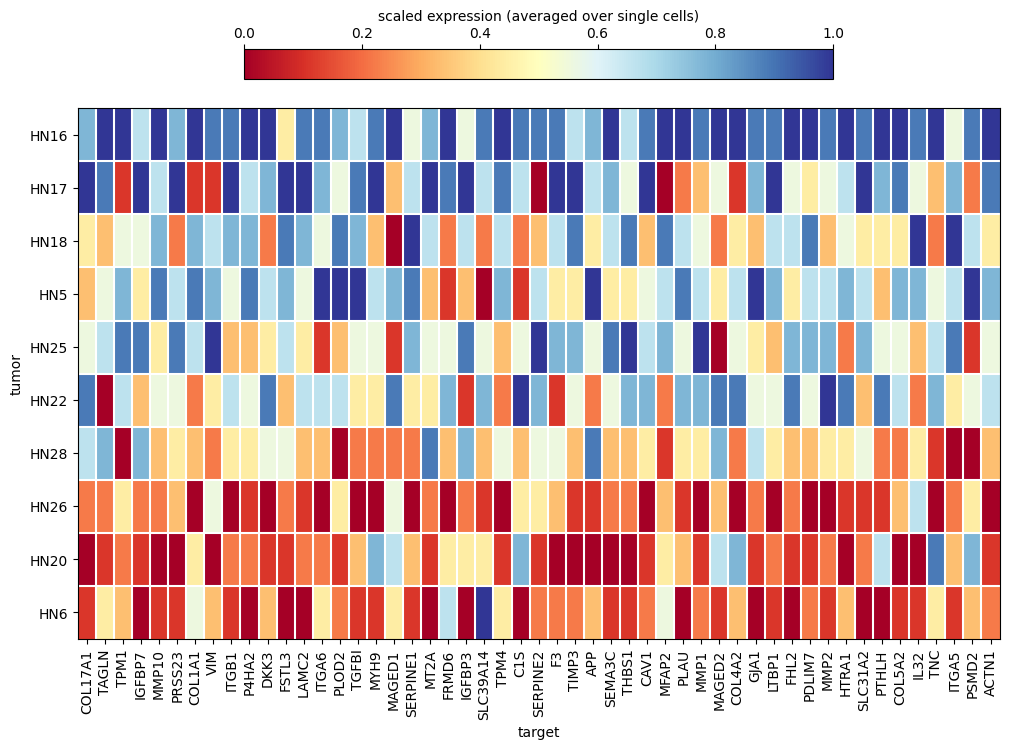

In [22]:
fig, ax = heatmap_2d(
    quantile_transform(agg_exp_target.values, n_quantiles=len(tumors)),
    xlabels=agg_exp_target.columns,
    ylabels=agg_exp_target.index,
    xtitle="target",
    ytitle="tumor",
    cbar_label="scaled expression (averaged over single cells)",
    cmap="RdYlBu",
    figsize=(10, 7)
)